In [461]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [462]:
data="data/NGC7814_rotmod.dat"
df=pd.read_csv(data,sep='\s+',
    comment="#",
    header=None)

In [463]:
# Assign column names
df.columns = [
    "Rad", "Vobs", "errV",
    "Vgas", "Vdisk", "Vbul",
    "SBdisk", "SBbul"
]

In [464]:
df['Vtheo']=(df['Vgas']**2 + df['Vbul']**2 + df['Vdisk']**2) ** (1/2)

In [465]:
df

,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul,Vtheo
0,0.63,265.0,15.00,-0.69,39.69,345.22,482.94,6648.99,347.494778
1,1.72,250.0,15.00,-2.33,81.63,298.99,314.38,709.44,309.941778
2,2.79,233.0,7.29,-3.94,104.82,255.24,206.27,199.44,275.953282
3,3.91,230.0,6.45,-5.06,118.95,225.30,132.93,74.66,254.823068
4,5.03,228.0,5.37,-3.48,122.96,203.41,76.78,26.96,237.711801
5,6.14,228.0,5.16,1.40,120.03,186.27,47.70,9.82,221.598000
6,7.26,227.0,5.94,-1.38,115.88,172.25,31.38,3.55,207.605735
7,8.37,226.0,3.00,5.96,113.50,160.83,22.99,1.29,196.936692
8,9.50,223.0,3.92,11.22,109.97,151.12,14.94,0.47,187.233928
9,10.65,219.0,2.90,16.09,105.99,142.79,9.90,0.16,178.554620


In [466]:
import numpy as np

G = 4.3009e-6   # kpc (km/s)^2 / Msun
rho0 = 5e7
rc = 2

def iso_velocity(r, rho0, rc):

    term = 1 - (rc/r) * np.arctan(r/rc)

    return np.sqrt(
        4*np.pi*G*rho0*(rc**2)*term
    )


df["Vhalo"] = iso_velocity(
    df["Rad"],
    rho0,
    rc
)

In [467]:
def total_model(r, rho0, rc):

    vhalo = iso_velocity(r, rho0, rc)

    return np.sqrt(
        df["Vgas"]**2 +
        df["Vdisk"]**2 +
        df["Vbul"]**2 +
        vhalo**2
    )

params, cov = curve_fit(
    total_model,
    df["Rad"],
    df["Vobs"],
    p0=[5e7, 2]
)

rho0_fit, rc_fit = params

d:\Python Language\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [468]:
df['pred'] = total_model(
    df["Rad"],
    rho0_fit,
    rc_fit
)

chi2 = np.sum(
    ((df["Vobs"] - df["pred"])**2) /
    (df["errV"]**2)
)
chi2_red=chi2/(len(df)-2)
print("Chi-square =", chi2_red)


Chi-square = 8.387774568709876


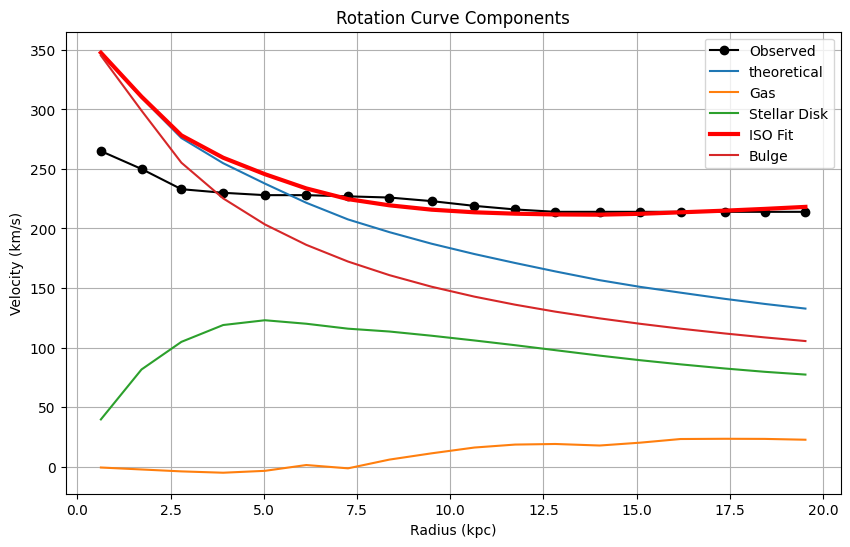

In [469]:
plt.figure(figsize=(10, 6))

plt.plot(df["Rad"], df["Vobs"], 'ko-', label="Observed")
plt.plot(df['Rad'],df['Vtheo'],label="theoretical")
plt.plot(df["Rad"], df["Vgas"], label="Gas")
plt.plot(df["Rad"], df["Vdisk"], label="Stellar Disk")
plt.plot(df["Rad"], df['pred'], 'r-', linewidth=3, label="ISO Fit")
if (df["Vbul"] > 0).any():
    plt.plot(df["Rad"], df["Vbul"], label="Bulge")

plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Rotation Curve Components")
plt.grid(True)
plt.legend()

plt.show()

In [470]:
df

,Rad,Vobs,errV,Vgas,Vdisk,Vbul,SBdisk,SBbul,Vtheo,Vhalo,pred
0,0.63,265.0,15.00,-0.69,39.69,345.22,482.94,6648.99,347.494778,18.374845,347.587658
1,1.72,250.0,15.00,-2.33,81.63,298.99,314.38,709.44,309.941778,43.381376,310.710812
2,2.79,233.0,7.29,-3.94,104.82,255.24,206.27,199.44,275.953282,58.796459,278.185635
3,3.91,230.0,6.45,-5.06,118.95,225.30,132.93,74.66,254.823068,68.836802,259.440462
4,5.03,228.0,5.37,-3.48,122.96,203.41,76.78,26.96,237.711801,75.396878,245.606398
5,6.14,228.0,5.16,1.40,120.03,186.27,47.70,9.82,221.598000,79.920984,233.657657
6,7.26,227.0,5.94,-1.38,115.88,172.25,31.38,3.55,207.605735,83.260585,224.663170
7,8.37,226.0,3.00,5.96,113.50,160.83,22.99,1.29,196.936692,85.778682,219.461387
8,9.50,223.0,3.92,11.22,109.97,151.12,14.94,0.47,187.233928,87.789213,215.805075
9,10.65,219.0,2.90,16.09,105.99,142.79,9.90,0.16,178.554620,89.429091,213.599290
